### Applying Isolation Forest algorithm to flag unstable satellites
- We will now train Isolation forest on each satellite cluster 

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest


In [106]:
# 1. Read the unscaled clustered dataset
unscaled_df = pd.read_csv('../data/05_labeled/satellites_unscaled_labeled.csv')
# 2. Read the scaled clustered dataset
scaled_df = pd.read_csv('../data/05_labeled/satellites_scaled_labeled.csv')

In [107]:
unscaled_df.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,2025-11-24 00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,900,4320,0.000861,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,2025-11-23 19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,902,82849,0.000074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,2025-11-23 16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,1512,93266,0.000132,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,2025-11-23 22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,1520,93529,0.000215,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2025-11-23 23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,2826,3595,0.001312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


---
## 🛰️ Cluster-Wise Isolation Forest: Abstract Workflow

Below is a high-level, implementation-agnostic explanation of how to run
**Isolation Forest separately on each cluster**, with parameters that adapt
to each cluster’s size and spread.

---

### 1. **Prepare Cluster Subsets**
After clustering (e.g., via K-Means), split the dataset into groups:

- Each group represents one cluster.
- Each cluster is treated as its own “local data pocket.”
- Compute basic stats per cluster:
  - `nᵢ` → number of points  
  - `σᵢ` → average standard deviation (or IQR) -> take average sd of every feature

These two values guide all later parameter choices.

---

### 2. **Set Cluster-Specific Parameters**
For every cluster **Cᵢ**:

**a. n_estimators (tree count)**  
Adjust based on cluster size:
- Small clusters → fewer trees  
- Medium → moderate  
- Large → slightly more

**b. max_samples**  
Use the smaller of:
- the cluster size,  
- a fixed cap (traditional ≈ 256)

This keeps trees consistent but efficient.

**c. contamination**  
Link sensitivity to cluster spread:
- Tight/compact clusters → very low contamination  
- Medium spread → moderate  
- High-spread/noisy clusters → slightly higher

This makes each model respect its own local variance.

**d. max_features**  
Use all features inside each cluster.  
Local models benefit from full context.

**e. bootstrap**  
Only enable if the cluster is very large.

---

### 3. **Train a Local Isolation Forest Inside Each Cluster**
- Fit the detector using that cluster’s own data only.
- The model isolates anomalies relative to the internal geometry of the cluster.
- No global interference from other clusters.

This produces cluster-wise anomaly scores.

---

### 4. **Normalize Scores Inside Each Cluster**
Each cluster’s score distribution is different.

Normalize scores cluster-wise, for example:
- min–max scaling  
- or z-score

This ensures that anomaly scores across clusters become comparable.

---

### 5. **Merge All Results**
Bring everything back together:

- Reattach the cluster label  
- Append the normalized anomaly score  
- Combine all cluster outputs into one final dataframe

The final result gives:
- local anomaly detection quality  
- global comparability  
- very stable and interpretable behavior

---

### 🧭 Outcome
You get a lightweight, cluster-sensible anomaly system where:
- each cluster has a detector tuned to its density and size  
- anomaly detection is cleaner and more precise  
- merged scores reflect global anomaly significance without distortion

This structure is simple, scalable, and strong for datasets with natural subgroups
(e.g., orbital shells, behavioral clusters, sensor regimes, etc.).


---


- Check the raw size of the clusters

In [108]:
scaled_df['CLUSTER'].value_counts()

CLUSTER
2    4842
0    2398
1    2273
4    1964
3    1126
Name: count, dtype: int64

---
### 1. Basic stats for each cluster -> Use scaled dataset for unbiased Standard Deviation
1. Satellite count
2. Average standard deviation across numerical features

In [109]:
# Find number of samples and mean SD 
def compute_base_stats(scaled_df):

    cluster_size_list = []
    sd_list = []
    value_counts = scaled_df['CLUSTER'].value_counts()
    
    # For each cluster: compute clust size and average SD
    for clust_id in sorted(value_counts.index):
        # --- clust size ---
        cluster_size_list.append(value_counts.loc[clust_id]) 
        
        # --- Average SD ---
        clust_rows = scaled_df[scaled_df['CLUSTER'] == clust_id] # filter out only this cluster satellites

        numeric_cols = clust_rows.select_dtypes(include = np.number).drop(columns=['CLUSTER']) # get numeric column names
        encoded_cols = [col for col in numeric_cols.columns if col.startswith('SAT_TYPE_')] # Filter out encoded features, as we dont need them for SD
        numeric_cols = numeric_cols.drop(columns = encoded_cols).columns
        
        total_sd = 0 # Find the SD for each feature, then add the SD for the current cluster's all features
        for feature in numeric_cols:
            sd = clust_rows[feature].std()
            total_sd += sd

        avg_sd = total_sd / len(numeric_cols) 
        sd_list.append(avg_sd)
        
    return cluster_size_list, sd_list
        

In [110]:
# Call the function
cluster_size, avg_sd = compute_base_stats(scaled_df)

In [111]:
cluster_size

[np.int64(2398),
 np.int64(2273),
 np.int64(4842),
 np.int64(1126),
 np.int64(1964)]

In [112]:
avg_sd

[0.7216778483149409,
 0.44313471114843517,
 0.3892258297958157,
 0.808735633447819,
 0.69629393581042]

----
### 2. Setting cluster specific parameters for Isolation Forest models
- For each cluster based on the size and Average SD, find:
1. **n_estimators**: Tree count
2. **max_samples**:  Num of samples to use in each isolation tree
3. **contamination**: Threshold by which anomaly will be selected
4. **max_features**: Use all features in every tree

---
## Mapping Cluster Stats → Isolation Forest Parameters (Intuition + Value Ranges)

### Inputs:
- **cluster_size** → number of satellites in this cluster  
- **cluster_sd** → how spread-out the cluster is (average SD of continuous features)

These two fully define how the Isolation Forest should be shaped.

---

## 1. contamination (comes from cluster_sd)

### Intuition:
“Tight cluster → fewer anomalies. Loose cluster → more anomalies.”

### Suggested values:
- **Low SD** (very tight) → `0.01` to `0.02`  
- **Medium SD** → `0.03` to `0.06`  
- **High SD** (very loose) → `0.08` to `0.12`  

---

## 2. n_estimators (comes from cluster_size)

### Intuition:
“Bigger clusters have more structure → need more trees.”

### Suggested values:
- **cluster_size < 100** → `50–100` trees  
- **100 ≤ size ≤ 1000** → `150–200` trees  
- **size > 3000** → `250–350` trees  

---

## 3. max_samples (also from cluster_size)

### Intuition:
“Small cluster → smaller subsamples. Big cluster → bigger subsamples.”

### Suggested values:
- **cluster_size < 100** → `40–80%` of the cluster  
- **100 ≤ size ≤ 1000** → `60–90%` of the cluster  
- **size > 3000** → fixed cap like `512` or `1024` samples  

---

## Summary Mapping
- **cluster_sd → contamination**  
- **cluster_size → n_estimators**  
- **cluster_size → max_samples**  

These three settings adjust the Isolation Forest to each cluster’s personality.


----
### Final value tables
#### 1. Contamination rule: 



Contamination is chosen by first selecting a system-wide range:
- Tight system  →  0.005 to 0.03  
- Normal system →  0.01  to 0.08  
- Loose system  →  0.02  to 0.12  

The chosen range is stretched across k positions (k = number of clusters) to form a smooth scale of contamination values from minimum to maximum.  
Cluster SD ordering determines each cluster’s position on this scale: tighter SD maps to lower contamination, looser SD maps to higher contamination, and identical SD values map to the same position.


---

#### 2. n_estimators rule: 
| Cluster Size Range | Meaning      | Recommended n_estimators |
| ------------------ | ------------ | ------------------------ |
| **< 100**          | Very Small   | **50–80**                |
| **100–1000**       | Small–Medium | **150–200**              |
| **1000–3000**      | Medium–Large | **200–250**              |
| **> 3000**         | Very Large   | **250–350**              |


---

#### 3. max_samples rule:
| Cluster Size Range | Meaning      | Recommended max_samples                      |
| ------------------ | ------------ | -------------------------------------------- |
| **< 100**          | Very Small   | **40–80%** of cluster size                   |
| **100–1000**       | Small–Medium | **60–90%** of cluster size                   |
| **1000–3000**      | Medium–Large | **approx 90–95%** of cluster size            |
| **> 3000**         | Very Large   | **Fixed cap: 512–1024** (regardless of size) |



In [113]:
def find_model_parameter(clust_sd, cluster_size):
    # df = scaled_df (just for this function)

    contamination_list, n_estimator_list, max_sample_list = [None]*len(clust_sd), [None]*len(clust_sd), [None]*len(clust_sd)

    # 1. Contamination (based on cluster SD)

    # Step 1: Compute SD spread
    spread = max(clust_sd) - min(clust_sd)
    
    # Step 2: Choose min/max contamination based on spread
    if spread <= 0.2:
        min_cont, max_cont = 0.005, 0.03
    elif spread <= 0.6:
        min_cont, max_cont = 0.01, 0.08
    else:
        min_cont, max_cont = 0.02, 0.12
    
    # Step 3: Generate contamination values (dynamic for any k)
    selected_sd_range = np.linspace(min_cont, max_cont, len(clust_sd))
    
    # Step 4: Group clusters by SD (equal SD → equal contamination)
    unique_sds = sorted(set(clust_sd))
    sd_to_rank = {sd: i for i, sd in enumerate(unique_sds)}
    
    # Step 5: Assign contamination using grouped ranks
    for i in range(len(clust_sd)):
        rank = sd_to_rank[clust_sd[i]] # which rank does the cluster with This SD has
        contamination_list[i] = selected_sd_range[rank]

    # ----------------------------------------------------------
    
    # 2. n_estimators &  max_samples (based on cluster size)

    for i in range(len(cluster_size)):
        if cluster_size[i] < 100: # Small sized cluster
            n_estimator_list[i] = 70
            max_sample_list[i] = int(cluster_size[i] * 0.5)
            
        elif cluster_size[i] <1000: # small to medium sized cluster
            n_estimator_list[i] = 150
            max_sample_list[i] = int(cluster_size[i] * 0.7)

        elif cluster_size[i] <3000: #  medium to large sized cluster
            n_estimator_list[i] = 200
            max_sample_list[i] = int(cluster_size[i] * 0.9)
            
        else:                     # Large sized cluster
            n_estimator_list[i] = 350
            max_sample_list[i] = 1000
     # ----------------------------------------------------------

    return contamination_list, n_estimator_list, max_sample_list
    
        

In [114]:
contamination_list, n_estimator_list, max_sample_list = find_model_parameter(avg_sd, cluster_size)

In [115]:
print(f"{'Cluster ID':<12} | {'Contamination':<15} | {'n_estimators':<12} | {'max_samples':<12}")
print("-" * 65)

for i in range(len(cluster_size)):
    print(f"{str(i):<12} | {contamination_list[i]:<15} | {n_estimator_list[i]:<12} | {max_sample_list[i]:<12}")


Cluster ID   | Contamination   | n_estimators | max_samples 
-----------------------------------------------------------------
0            | 0.0625          | 200          | 2158        
1            | 0.027500000000000004 | 200          | 2045        
2            | 0.01            | 350          | 1000        
3            | 0.08            | 200          | 1013        
4            | 0.045000000000000005 | 200          | 1767        


In [116]:
cluster_size

[np.int64(2398),
 np.int64(2273),
 np.int64(4842),
 np.int64(1126),
 np.int64(1964)]

In [117]:
print(f"{'Cluster ID':<12} | {'Contamination':<15} | {'n_estimators':<12} | {'max_samples':<12}")
print("-" * 65)

for i in range(len(cluster_size)):
    print(f"{str(i):<12} | {contamination_list[i]:<15} | {n_estimator_list[i]:<12} | {max_sample_list[i]:<12}")

Cluster ID   | Contamination   | n_estimators | max_samples 
-----------------------------------------------------------------
0            | 0.0625          | 200          | 2158        
1            | 0.027500000000000004 | 200          | 2045        
2            | 0.01            | 350          | 1000        
3            | 0.08            | 200          | 1013        
4            | 0.045000000000000005 | 200          | 1767        


---

### Training Isolation Forest on each cluster

In [118]:
unscaled_df.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,2025-11-24 00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,900,4320,0.000861,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,2025-11-23 19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,902,82849,0.000074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,2025-11-23 16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,1512,93266,0.000132,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,2025-11-23 22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,1520,93529,0.000215,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2025-11-23 23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,2826,3595,0.001312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


##### Because we are using unscaled DF for training, we will need to remove following columns :
1. Epoch
2. Norad cat ID

In [119]:
unscaled_df = unscaled_df.drop(columns=['EPOCH', 'NORAD_CAT_ID'])

In [120]:
# Function to train model
def train_iso_model(df, contamination, n_estimator, max_sample):

    iso_forest_models = {} # Store cluster ID: related iso model
    
    for cluster_id in sorted(list(set(df['CLUSTER']))):
        # Extract rows for this cluster ID
        cluster_rows = df[df['CLUSTER'] == cluster_id]

        iso_model = IsolationForest(n_estimators=n_estimator[cluster_id], 
                                   max_samples=max_sample[cluster_id],
                                   contamination=contamination[cluster_id],
                                   max_features=1.0, # Consider all features in a tree
                                   random_state=101)
        # Train the model
        iso_model.fit(cluster_rows.drop(columns=['CLUSTER']))
        iso_forest_models[cluster_id] = iso_model # Save the model to the dictionary

        print(f'Isolation forest trained for cluster {cluster_id}')

    return iso_forest_models

In [121]:
# Call the function to train (on unscaled dataset -> Isolation forest does not need scaling)
iso_forest_models = train_iso_model(unscaled_df, contamination_list, n_estimator_list, max_sample_list)

Isolation forest trained for cluster 0
Isolation forest trained for cluster 1
Isolation forest trained for cluster 2
Isolation forest trained for cluster 3
Isolation forest trained for cluster 4


In [122]:
iso_forest_models

{0: IsolationForest(contamination=np.float64(0.0625), max_samples=2158,
                 n_estimators=200, random_state=101),
 1: IsolationForest(contamination=np.float64(0.027500000000000004),
                 max_samples=2045, n_estimators=200, random_state=101),
 2: IsolationForest(contamination=np.float64(0.01), max_samples=1000,
                 n_estimators=350, random_state=101),
 3: IsolationForest(contamination=np.float64(0.08), max_samples=1013,
                 n_estimators=200, random_state=101),
 4: IsolationForest(contamination=np.float64(0.045000000000000005),
                 max_samples=1767, n_estimators=200, random_state=101)}

In [123]:
# function to extract the anomaly information
def get_anomaly(iso_forest_models, df):

    # Prepare the anomaly realted features
    df['ANOMALY_LABEL'] = 0
    df['ANOMALY_SCORE'] = 0.0
    
    for cluster_id, model in iso_forest_models.items():
        # Select all rows belonging to this cluster
        mask = df['CLUSTER'] == cluster_id

        # Extract necessary features (features + rows belonging to the cluster)
        features = df.loc[mask].drop(columns=['CLUSTER', 'ANOMALY_LABEL', 'ANOMALY_SCORE'])

        # Predict using model trained on exact features
        labels = model.predict(features) 
        score = model.decision_function(features)

        # Store the results back to unscaled DF
        df.loc[mask, 'ANOMALY_LABEL'] = labels
        df.loc[mask, 'ANOMALY_SCORE'] = score

        print(f'Isolation forest predicted for cluster {cluster_id}')

    return df

In [124]:
anomaly_df = get_anomaly(iso_forest_models, unscaled_df)

Isolation forest predicted for cluster 0
Isolation forest predicted for cluster 1
Isolation forest predicted for cluster 2
Isolation forest predicted for cluster 3
Isolation forest predicted for cluster 4


In [125]:
anomaly_df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,4320,0.000861,8.510000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,-1,-0.041288
1,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,82849,0.000074,5.800000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,-1,-0.038372
2,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,93266,0.000132,7.500000e-07,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,-1,-0.021454
3,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,93529,0.000215,1.200000e-06,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,-1,-0.058126
4,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,3595,0.001312,8.522000e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,-1,-0.031365


----


### Interpreting the results

#### 1. Sort satellites in that cluster by anomaly severity

In [126]:
def anomaly_severity(cluster_id, df):
    # Get anomalies from this cluster id sorted by anomaly score
    cluster_df = df[df['CLUSTER']==cluster_id].sort_values(by='ANOMALY_SCORE')

    # Get top 10 risky satellites
    top_10 = cluster_df.head(10)
    return top_10, cluster_df
    

In [127]:
print('top 10 anomalous satellites within each cluster')
for i in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the functon
    top_10, cluster_df = anomaly_severity(i, anomaly_df)

    print('-----------------------')
    print(f'Cluster ID {i}')
    print(top_10[['ANOMALY_SCORE']])
    print('\n')

top 10 anomalous satellites within each cluster
-----------------------
Cluster ID 0
       ANOMALY_SCORE
5767       -0.165501
827        -0.150456
1220       -0.143175
4517       -0.138942
9939       -0.136937
3833       -0.131483
2028       -0.121969
1394       -0.106337
11353      -0.105887
6857       -0.085908


-----------------------
Cluster ID 1
      ANOMALY_SCORE
3919      -0.214382
1979      -0.190221
848       -0.144711
201       -0.134043
7557      -0.098520
7556      -0.091560
28        -0.064509
2036      -0.062501
9133      -0.054509
709       -0.053343


-----------------------
Cluster ID 2
       ANOMALY_SCORE
4450       -0.134887
11897      -0.117369
1114       -0.115375
6637       -0.106996
5624       -0.095836
7411       -0.088024
9758       -0.087938
776        -0.081428
4880       -0.073204
1206       -0.070916


-----------------------
Cluster ID 3
      ANOMALY_SCORE
230       -0.277936
178       -0.152221
101       -0.131458
2452      -0.124433
202       -0.105

---
#### 2. Anomaly distribution to see cluster behavior

##### A. Score distribution plot (1D histogram / KDE)

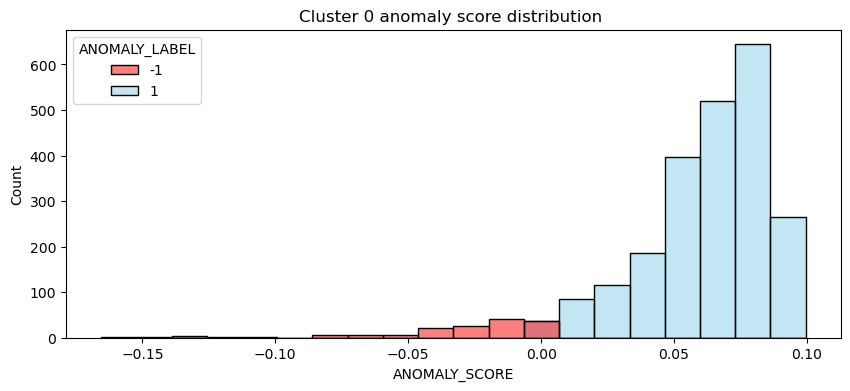

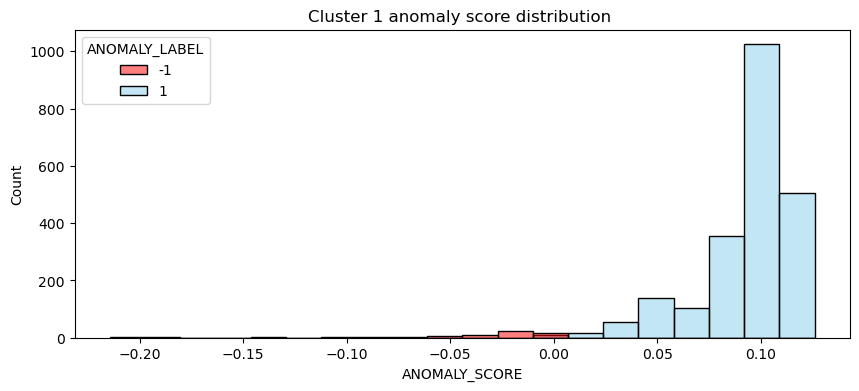

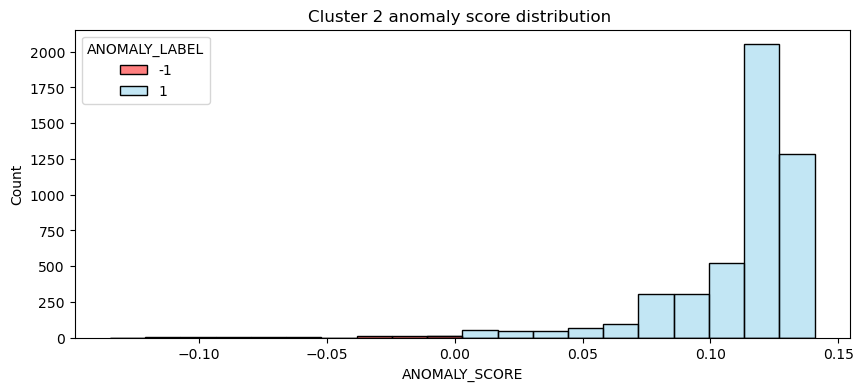

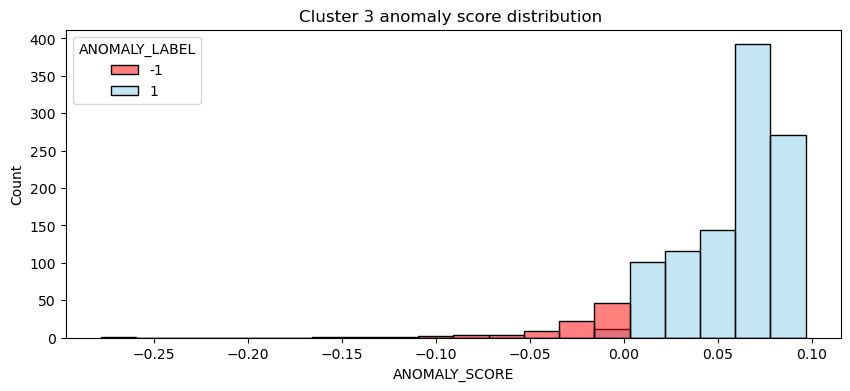

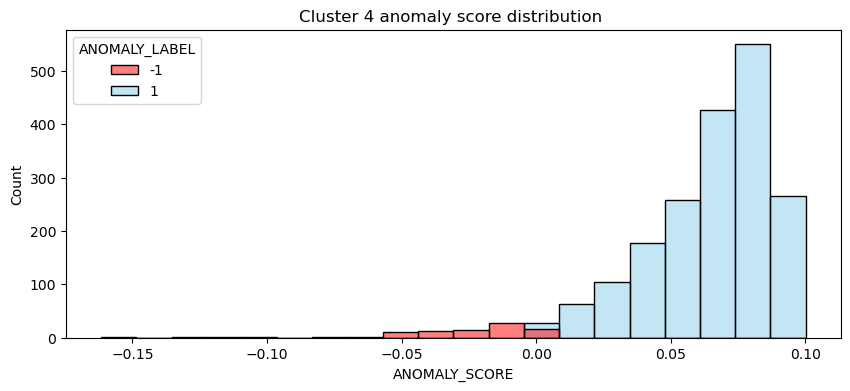

In [128]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} anomaly score distribution ')
    sns.histplot(data =cluster_df,x = 'ANOMALY_SCORE', bins=20, hue='ANOMALY_LABEL', palette={1: "skyblue", -1: "red"})

#### B. 2D scatter: Altitude vs Mean Motion

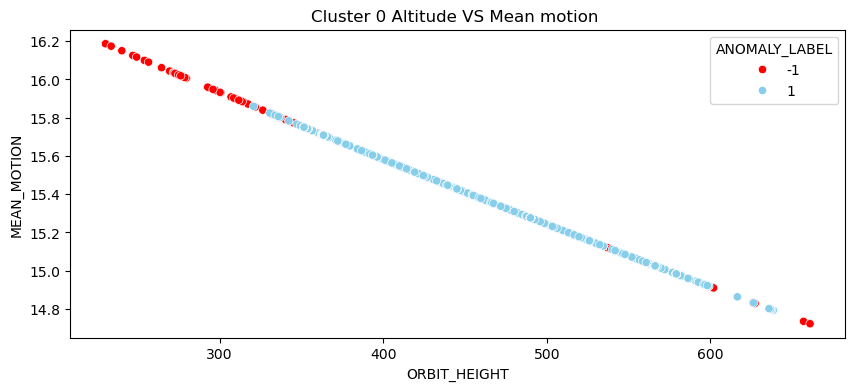

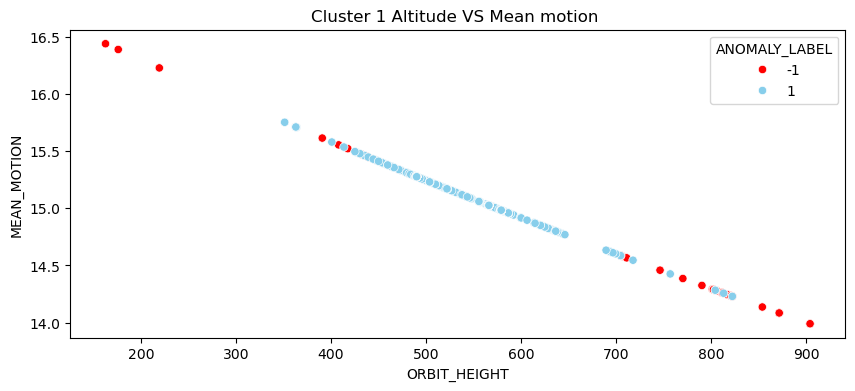

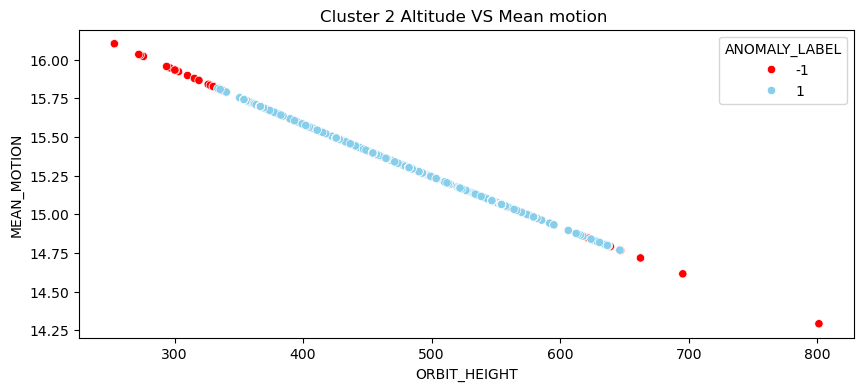

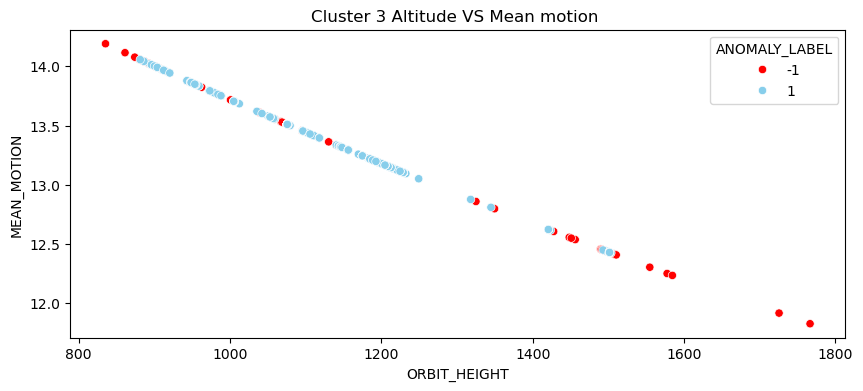

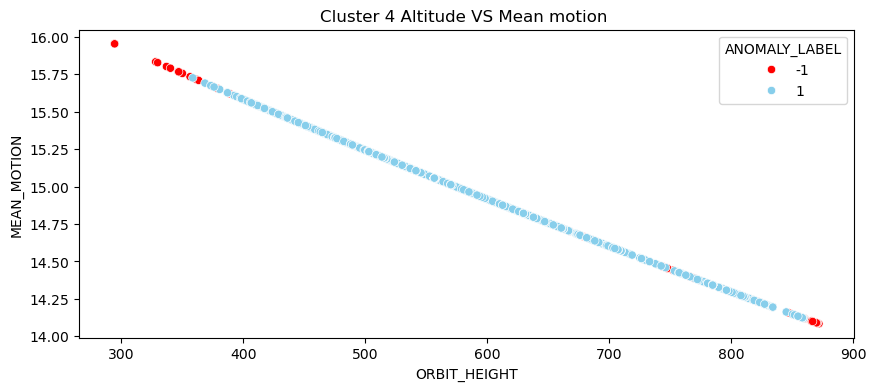

In [129]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} Altitude VS Mean motion ')
    sns.scatterplot(data = cluster_df,x = 'ORBIT_HEIGHT', y = 'MEAN_MOTION', hue='ANOMALY_LABEL', palette={1: "skyblue", -1: "red"})

#### C. 2D scatter: BSTAR vs Altitude 

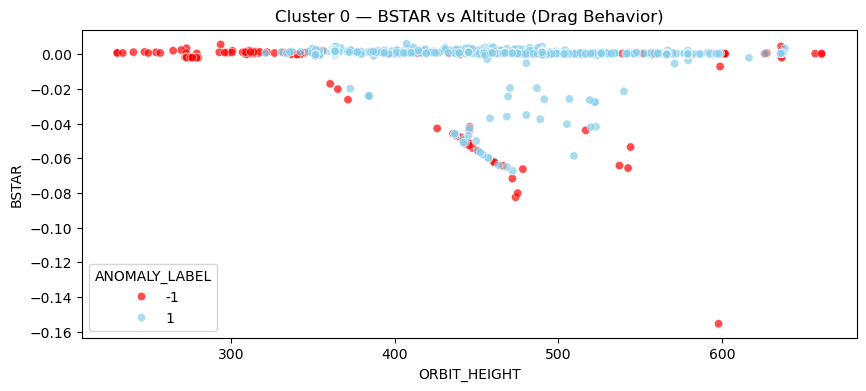

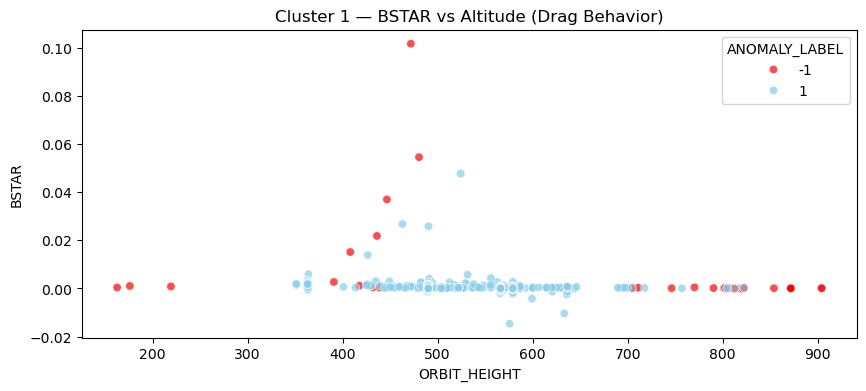

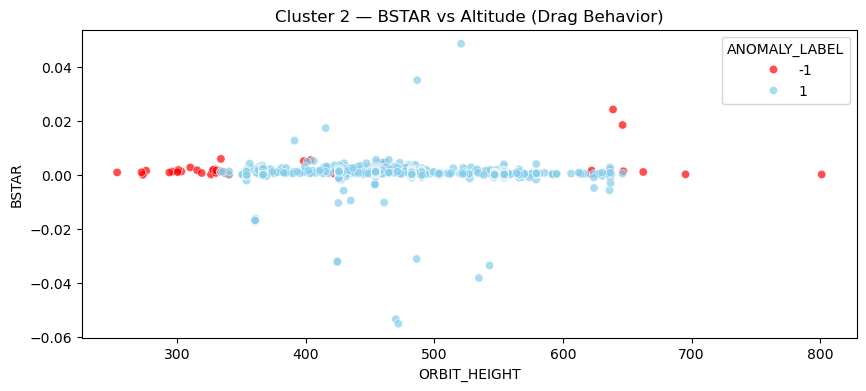

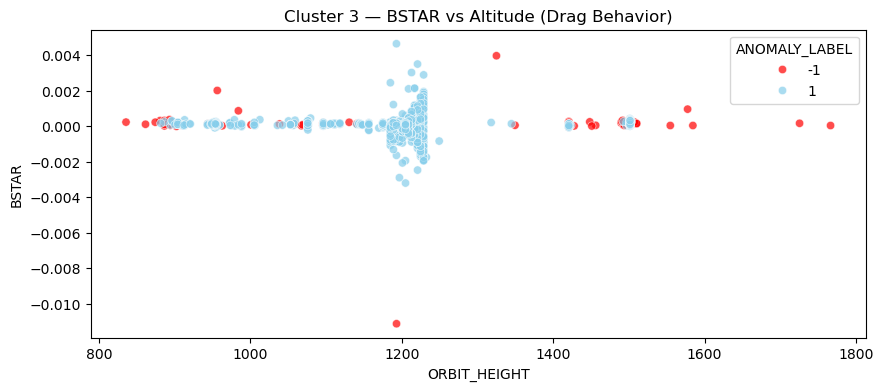

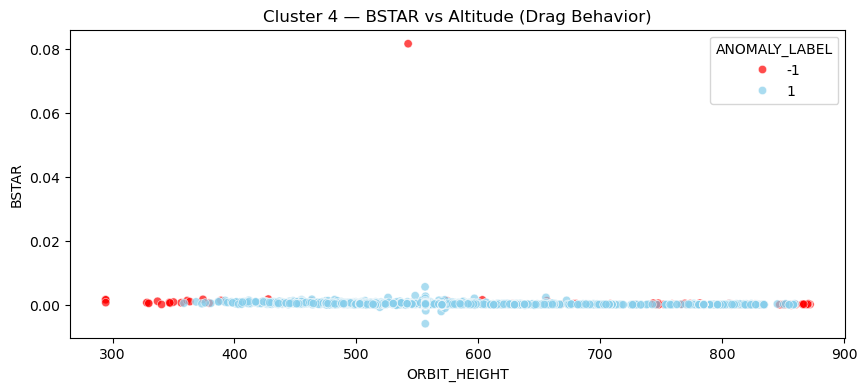

In [130]:
for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)
    
    plt.figure(figsize=(10, 4))
    plt.title(f'Cluster {cluster_id} — BSTAR vs Altitude (Drag Behavior)')
    sns.scatterplot(
        data=cluster_df,
        x='ORBIT_HEIGHT',
        y='BSTAR',
        hue='ANOMALY_LABEL',
        palette={1: "skyblue", -1: "red"},
        alpha=0.7
    )
  

----


### 3. Per-Anomaly Feature Deviation Detection

In [131]:
# All anomaly feature deviation (concat after each loop)
all_anomalies = []

for cluster_id in range(0, anomaly_df['CLUSTER'].nunique()):
    # Call the function
    top_10, cluster_df = anomaly_severity(cluster_id, anomaly_df)

    # Compute cluster means for selected features (important features)
    features = [
     "ORBIT_HEIGHT",
     "MEAN_MOTION",
     "ECCENTRICITY",
     "INCLINATION",
     "RA_OF_ASC_NODE",
     "ARG_OF_PERICENTER",
     "BSTAR",
     "PERIGEE",
     "APOGEE",
     "SEMI_MAJOR_AXIS",
     "ORBITAL_SPEED"
    ]
    cluster_mean = cluster_df[features].mean()

    # Get anomaly satellites
    anomalies = cluster_df[cluster_df['ANOMALY_LABEL']== -1].copy()

    # For each anomaly satellite:
    for i, row in anomalies.iterrows():
        # Store deviations for this satellite
        delta_dict = {}

        # Compare each feature value to the cluster mean
        for feature in features:
            delta = abs(row[feature] - cluster_mean[feature])

            delta_dict[feature] = delta

        # Identify heighest deviation feature(s)
        max_delta_value = max(delta_dict.values())
        max_delta_feature = max(delta_dict, key=delta_dict.get)

        # Attach this info into the dataframe for reporting/explaination
        anomalies.loc[i, 'TOP_DEVIATING_FEATURE'] = max_delta_feature
        anomalies.loc[i, 'TOP_DELTA_VALUE'] = max_delta_value

    all_anomalies.append(anomalies)

final_anomalies = pd.concat(all_anomalies, ignore_index=True)

In [132]:
final_anomalies

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE,TOP_DEVIATING_FEATURE,TOP_DELTA_VALUE
0,16.032211,0.000154,53.1315,309.9962,119.4595,270.8901,606,0.003504,0.021107,0.003356,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.165501,RA_OF_ASC_NODE,225.876261
1,16.186048,0.000465,52.9751,183.2792,217.2268,142.8447,32778,0.000770,0.013348,0.001455,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.150456,PERIGEE,256.163426
2,16.150234,0.000614,53.0261,164.6540,240.5528,119.4895,28534,0.001231,0.016236,0.002210,...,1.0,0.0,0.0,0.0,0.0,0,-1,-0.143175,PERIGEE,247.400651
3,16.186822,0.000691,42.9888,173.4629,274.1603,85.8493,15354,0.000817,0.014488,0.001770,...,0.0,1.0,0.0,0.0,0.0,0,-1,-0.138942,PERIGEE,257.864294
4,15.956692,0.000981,97.3947,224.5812,134.9037,225.3037,3900,0.005670,0.021758,0.003101,...,0.0,0.0,0.0,0.0,0.0,0,-1,-0.136937,PERIGEE,196.525223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,15.486601,0.002118,97.7529,310.8969,106.6170,253.7407,65059,0.001824,0.000994,0.000000,...,0.0,0.0,0.0,0.0,1.0,4,-1,-0.001373,RA_OF_ASC_NODE,179.526389
437,15.654263,0.000270,97.1782,34.2198,61.7893,298.3640,77206,0.000592,0.000593,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000905,APOGEE,202.105665
438,15.243567,0.000263,97.7437,312.4508,0.8760,359.2480,95593,0.000754,0.000184,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000592,RA_OF_ASC_NODE,181.080289
439,15.671459,0.000302,97.5255,39.0058,49.8104,310.3420,13393,0.001742,0.001900,0.000000,...,0.0,0.0,0.0,0.0,0.0,4,-1,-0.000525,APOGEE,206.834797


In [133]:
final_anomalies['CLUSTER'].value_counts()

CLUSTER
0    150
3     90
4     89
1     63
2     49
Name: count, dtype: int64

In [134]:
anomaly_df['ANOMALY_LABEL'].value_counts()

ANOMALY_LABEL
 1    12162
-1      441
Name: count, dtype: int64

In [135]:
final_anomalies['TOP_DEVIATING_FEATURE'].value_counts()

TOP_DEVIATING_FEATURE
APOGEE               208
PERIGEE              155
ARG_OF_PERICENTER     42
RA_OF_ASC_NODE        36
Name: count, dtype: int64